# Projeto: Modelo Preditivo de Risco de Crédito
## Desenvolvimento de ferramenta para suporte à decisão de concessão de crédito.  
### Objetivo: Identificar o perfil de clientes com maior probabilidade de inadimplência utilizando o dataset histórico.

## Importação das bibliotecas

In [54]:

import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None) #Para mostrar todas as colunas
pd.set_option('display.float_format', '{:.2f}'.format) #Para formatar decimais

## Importando df e renomeando as colunas

In [42]:
df = pd.read_csv('credit_risk_dataset.csv')
dicionario_nomes_colunas = {
    'person_age': 'idade',
    'person_income': 'renda_anual',
    'person_home_ownership': 'tipo_residencia',
    'person_emp_length': 'tempo_trabalho',
    'loan_intent': 'motivo_emprestimo',
    'loan_grade': 'nota_credito',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros',
    'loan_status': 'inadimplente',
    'loan_percent_income': 'percentual_comprometimento',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'tempo_historico_credito'
}
df = df.rename(columns=dicionario_nomes_colunas)
display(df.head())

,idade,renda_anual,tipo_residencia,tempo_trabalho,motivo_emprestimo,nota_credito,valor_emprestimo,taxa_juros,inadimplente,percentual_comprometimento,historico_inadimplencia,tempo_historico_credito
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


##Verificação de Integridade dos Dados (Valores Ausentes)

In [43]:
df.isnull().sum() #Notado que a coluna 'taxa_juros'e 'tempo_trabalho' possuem valores nulos, que tratarei na próxima etapa

idade                            0
renda_anual                      0
tipo_residencia                  0
tempo_trabalho                 895
motivo_emprestimo                0
nota_credito                     0
valor_emprestimo                 0
taxa_juros                    3116
inadimplente                     0
percentual_comprometimento       0
historico_inadimplencia          0
tempo_historico_credito          0
dtype: int64

Tratamento de Dados Ausentes
Identifiquei valores nulos nas variáveis taxa_juros e tempo_trabalho. Para manter a integridade da base e permitir o treinamento do modelo, realizarei a imputação por mediana.
(A tentativa por mediana se deve por ser uma medida de tendência rovusta a outliers garantindo que valores extremos não deixem o modelo enviesado).

In [44]:
mediana_juros = df['taxa_juros'].median()
mediana_tempo = df['tempo_trabalho'].median()

df['taxa_juros'] = df['taxa_juros'].fillna(mediana_juros)
df['tempo_trabalho'] = df['tempo_trabalho'].fillna(mediana_tempo)

print(df[['taxa_juros', 'tempo_trabalho']].isnull().sum())

taxa_juros        0
tempo_trabalho    0
dtype: int64


##Identificando inconsistências através da estatística descritiva.

In [45]:
df.describe()

,idade,renda_anual,tempo_trabalho,valor_emprestimo,taxa_juros,inadimplente,percentual_comprometimento,tempo_historico_credito
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.77,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


##Encontrado inconsistência na idade max e tempo de trabalho, aplicarei filtros para remover os registros.

In [46]:
df = df[ df['idade'] < 100]
df = df[ df['tempo_trabalho'] < 60]

df.describe()

,idade,renda_anual,tempo_trabalho,valor_emprestimo,taxa_juros,inadimplente,percentual_comprometimento,tempo_historico_credito
count,32574.00,32574.00,32574.00,32574.00,32574.00,32574.00,32574.00,32574.00
mean,27.72,65878.48,4.76,9588.02,11.01,0.22,0.17,5.80
std,6.20,52531.94,3.98,6320.25,3.08,0.41,0.11,4.05
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,94.00,2039784.00,41.00,35000.00,23.22,1.00,0.83,30.00


<Axes: xlabel='inadimplente'>

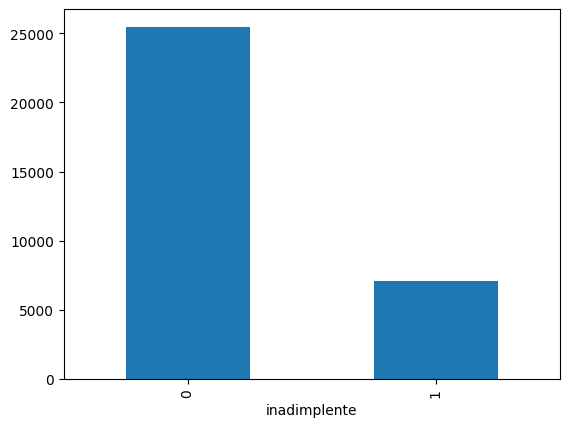

In [47]:
df['inadimplente'].value_counts().plot(kind='bar')

In [48]:
df['tipo_residencia'].value_counts()

tipo_residencia
RENT        16442
MORTGAGE    13441
OWN          2584
OTHER         107
Name: count, dtype: int64

In [ ]:
df = pd.DataFrame({'tipo_residencia': ['RENT', 'MORTGAGE', 'OWN', 'OTHER']})
df_encoded = pd.get_dummies(df, dtype=int, columns=['tipo_residencia'])
print(df_encoded)

   tipo_residencia_MORTGAGE  tipo_residencia_OTHER  tipo_residencia_OWN  \
0                     False                  False                False   
1                      True                  False                False   
2                     False                  False                 True   
3                     False                   True                False   

   tipo_residencia_RENT  
0                  True  
1                 False  
2                 False  
3                 False  


In [66]:
resultado = df_encoded[['tipo_residencia_MORTGAGE', 'tipo_residencia_OTHER', 'tipo_residencia_OWN', 'tipo_residencia_RENT']].sum(axis=1)
print(resultado)

0    1
1    1
2    1
3    1
dtype: int64
